# 타자의 경기 기록을 이용한 OPS 예측 모델

## 분석 주제
타자의 경기 기록을 이용하여 OPS를 예측하는 머신러닝 회귀 모델 개발

## 문제 정의
OPS는 타자의 공격력을 종합적으로 평가하는 대표적인 지표이다. 하지만 경기 전에는 OPS를 알 수 없으므로,
선수의 기본 타격 기록을 이용하여 OPS를 예측할 수 있는 머신러닝 모델을 개발하고자 한다.

## 분석 목적
타자의 기본 기록을 활용하여 OPS를 예측하고, 어떤 기록이 OPS에 가장 큰 영향을 미치는지 분석한다.

## 분석 가설
- **H0(귀무가설)**: 타자의 기본 기록은 OPS 예측에 유의한 영향을 미치지 않는다.
- **H1(대립가설)**: 타자의 기본 기록은 OPS 예측에 유의한 영향을 미친다.

## 변수 정의
- **독립변수(X)**: 타석(PA), 타수(AB), 안타(H), 2루타(2B), 3루타(3B), 홈런(HR), 볼넷(BB), 삼진(SO), 도루(SB), 타점(RBI), 득점(R)
- **종속변수(Y)**: OPS
- ※ 출루율(OBP)과 장타율(SLG)은 OPS 계산에 직접 사용되는 변수이므로 독립변수에서 제외

## 라이브러리 불러오기 및 설정

In [1]:
import platform
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

CSV_PATH = "타자.csv"
MIN_PA = 100          # 최소 타석 기준 (표본 신뢰도 확보)
RANDOM_STATE = 42
TEST_SIZE = 0.2        # Train 80% / Test 20%
CV_FOLDS = 5

FEATURES = ["타석", "타수", "안타", "2루타", "3루타", "홈런", "볼넷", "삼진", "도루", "타점", "득점"]
TARGET = "OPS"

### 한글 폰트 자동 설정

In [2]:
system = platform.system()
candidates = {
    "Windows": ["Malgun Gothic"],
    "Darwin": ["AppleGothic"],
    "Linux": ["NanumGothic", "Noto Sans CJK KR", "Noto Sans CJK JP"],
}.get(system, [])

available = {f.name for f in fm.fontManager.ttflist}
for name in candidates:
    if name in available:
        plt.rcParams["font.family"] = name
        break
else:
    print("경고: 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")

plt.rcParams["axes.unicode_minus"] = False

## 1. 데이터 로드 & 전처리

표본 신뢰도를 위해 타석 100 이상인 선수만 남깁니다.

In [3]:
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
print(f"원본 shape: {df.shape}")

df_f = df[df["타석"] >= MIN_PA].reset_index(drop=True)
print(f"타석 {MIN_PA} 이상 필터링 후 shape: {df_f.shape}")

df_model = df_f[["선수", "팀"] + FEATURES + [TARGET]].copy()
df_model.head()

원본 shape: (398, 48)
타석 100 이상 필터링 후 shape: (155, 48)


,선수,팀,타석,타수,안타,2루타,3루타,홈런,볼넷,삼진,도루,타점,득점,OPS
0,박찬호,KIA,595,516,148,18,2,5,62,69,27,42,75,0.722
1,최형우,KIA,549,469,144,30,1,24,67,98,1,86,74,0.928
2,위즈덤,KIA,486,424,100,20,1,35,52,142,3,85,73,0.856
3,오선우,KIA,474,437,116,17,1,18,34,158,0,56,58,0.755
4,김호령,KIA,381,332,94,26,3,6,34,94,12,39,46,0.793


## 2. 데이터 유형 확인

| 구분 | 내용 |
|---|---|
| 독립변수 | 수치형(비율척도) |
| 종속변수 | 수치형(연속형) |

In [4]:
df_model[FEATURES + [TARGET]].dtypes

타석       int64
타수       int64
안타       int64
2루타      int64
3루타      int64
홈런       int64
볼넷       int64
삼진       int64
도루       int64
타점       int64
득점       int64
OPS    float64
dtype: object

## 3. 결측치 확인

In [5]:
df_model[FEATURES + [TARGET]].isna().sum()

타석     0
타수     0
안타     0
2루타    0
3루타    0
홈런     0
볼넷     0
삼진     0
도루     0
타점     0
득점     0
OPS    0
dtype: int64

## 4. 이상치 확인 (Boxplot)

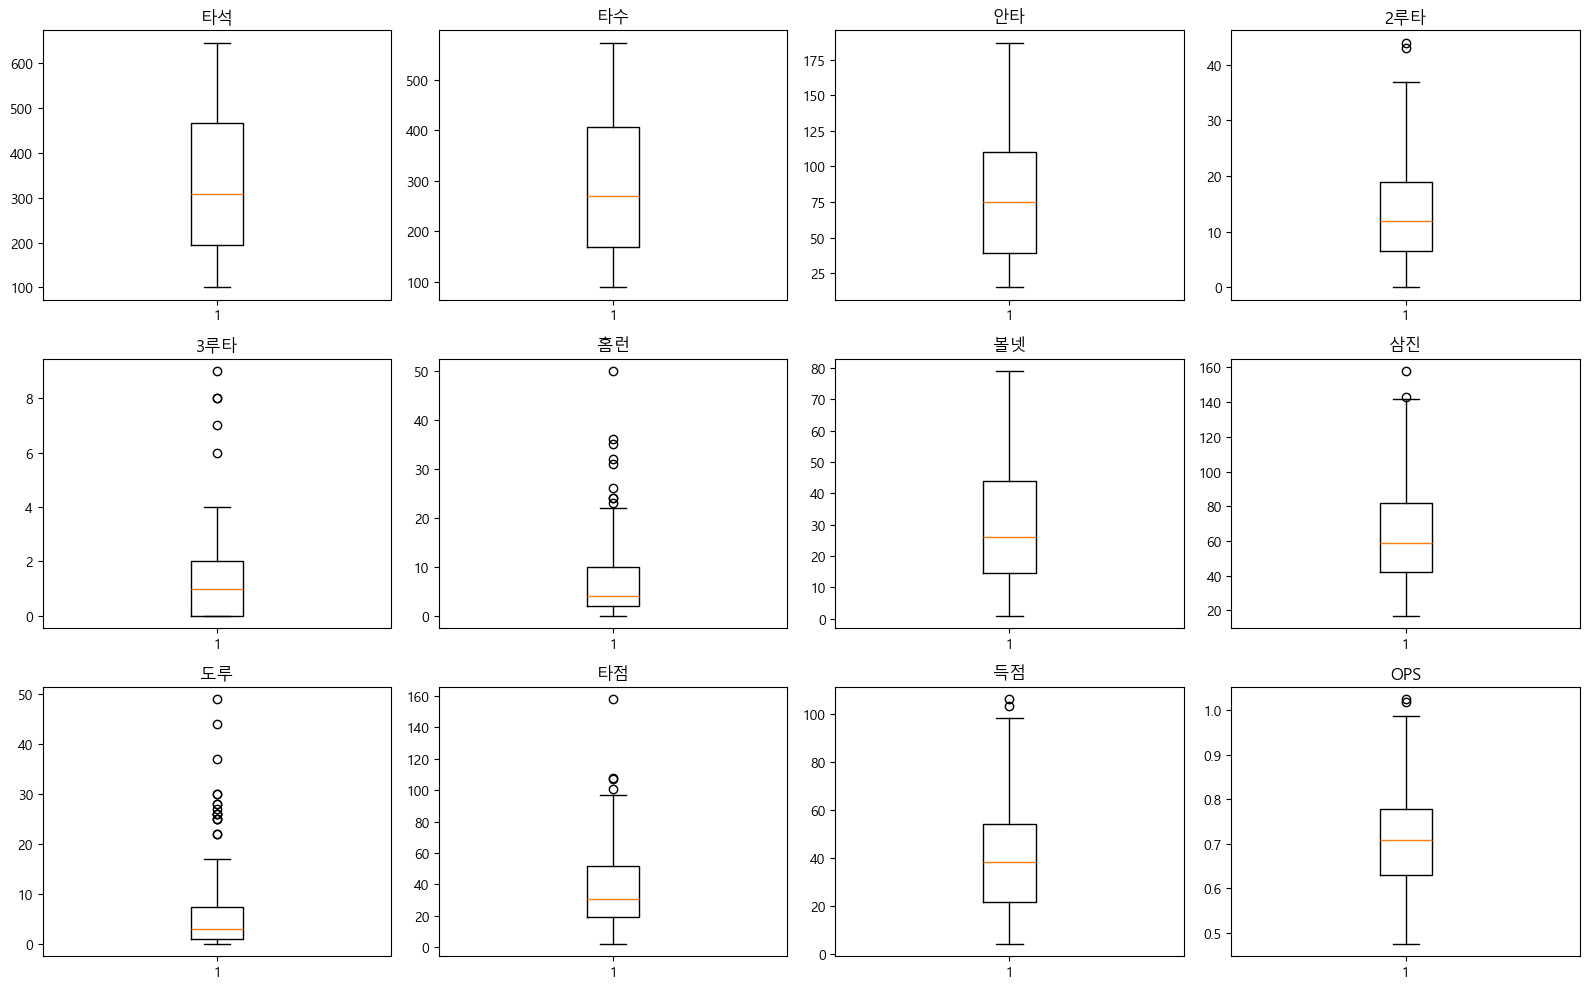

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURES + [TARGET]):
    axes[i].boxplot(df_model[col], vert=True)
    axes[i].set_title(col)

for j in range(len(FEATURES) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("boxplot_check.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. 변수 분포 (Histogram)

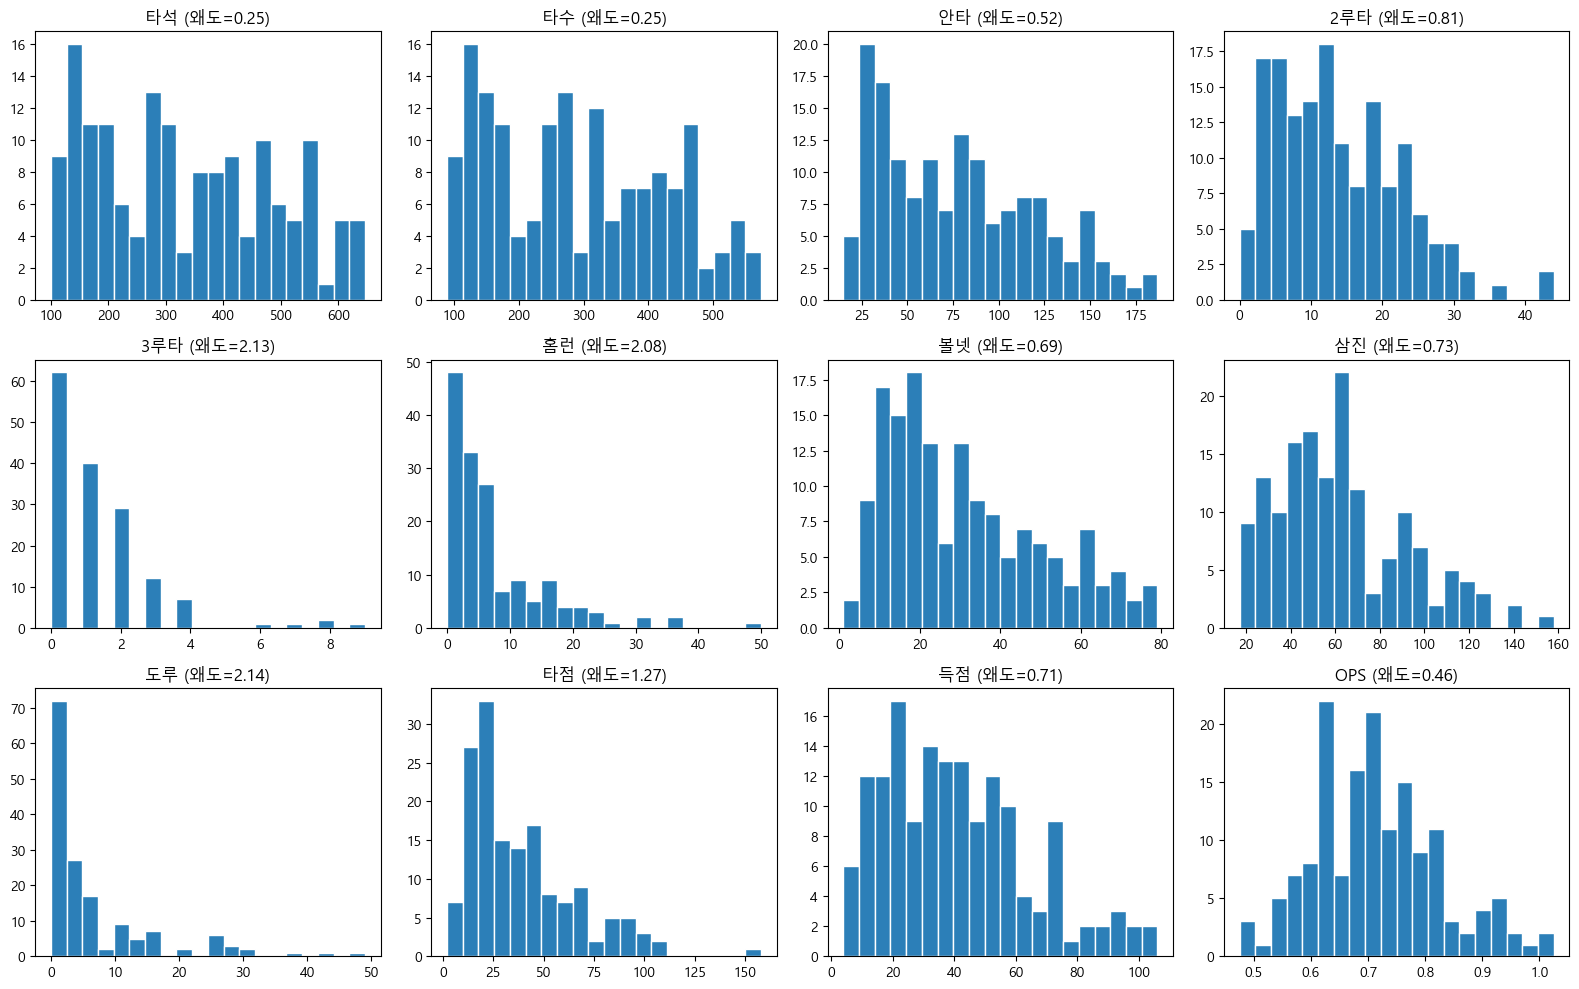

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURES + [TARGET]):
    axes[i].hist(df_model[col], bins=20, color="#2c7fb8", edgecolor="white")
    skew = stats.skew(df_model[col])
    axes[i].set_title(f"{col} (왜도={skew:.2f})")

for j in range(len(FEATURES) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("histogram_check.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 상관관계 분석

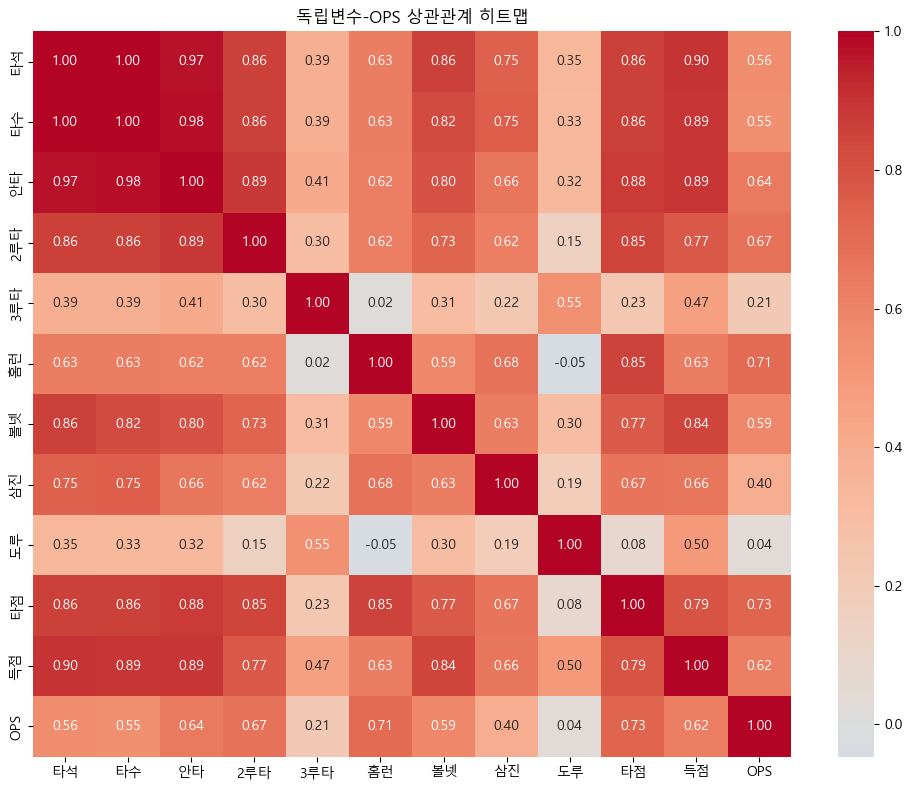

OPS와의 상관계수 (내림차순):
OPS    1.000000
타점     0.726447
홈런     0.706895
2루타    0.674007
안타     0.641561
득점     0.620289
볼넷     0.586777
타석     0.559905
타수     0.548202
삼진     0.395391
3루타    0.211560
도루     0.037444
Name: OPS, dtype: float64


In [8]:
corr = df_model[FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("독립변수-OPS 상관관계 히트맵")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("OPS와의 상관계수 (내림차순):")
print(corr[TARGET].sort_values(ascending=False))

## 7. 데이터 분할

지도학습(회귀) 문제이므로 Train/Test로 분할합니다.

```python
train_test_split(test_size=0.2, random_state=42)
```

In [9]:
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]}명 / Test: {X_test.shape[0]}명 "
      f"({int((1-TEST_SIZE)*100)}:{int(TEST_SIZE*100)})")

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
results = []

Train: 124명 / Test: 31명 (80:20)


## 8. 모델 개발

**지도학습 선택**: 회귀(Regression) — OPS는 연속형 수치 데이터이므로 회귀모델이 적합

### 모델 ① 선형회귀 (Linear Regression)
- 변수 간 선형 관계 확인 가능
- 결과 해석이 쉬움
- 기준(Baseline) 모델로 활용

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

lr_cv_r2 = cross_val_score(lr, X, y, cv=kf, scoring="r2")
lr_cv_mae = -cross_val_score(lr, X, y, cv=kf, scoring="neg_mean_absolute_error")

results.append({
    "모델": "Linear Regression",
    "Test MAE": round(lr_mae, 4),
    "Test RMSE": round(lr_rmse, 4),
    "Test R2": round(lr_r2, 4),
    "CV R2 평균": round(lr_cv_r2.mean(), 4),
    "CV R2 표준편차": round(lr_cv_r2.std(), 4),
    "CV MAE 평균": round(lr_cv_mae.mean(), 4),
})

print(f"Test MAE={lr_mae:.4f}  RMSE={lr_rmse:.4f}  R2={lr_r2:.4f}")
print(f"5-Fold CV R2 평균={lr_cv_r2.mean():.4f} (표준편차 {lr_cv_r2.std():.4f})")

Test MAE=0.0375  RMSE=0.0541  R2=0.7425
5-Fold CV R2 평균=0.7789 (표준편차 0.0357)


### 회귀계수 확인 (변수 영향력 해석)

In [11]:
coef_df = pd.DataFrame({
    "변수": FEATURES,
    "계수": lr.coef_
}).sort_values("계수", key=abs, ascending=False)
coef_df

,변수,계수
5,홈런,0.008519
4,3루타,0.006382
2,안타,0.006218
1,타수,-0.003640
3,2루타,0.003639
0,타석,0.001525
9,타점,-0.001234
8,도루,-0.000815
7,삼진,0.000327
6,볼넷,0.000199


### 모델 ② Random Forest Regressor
- 비선형 관계 학습 가능
- 변수 간 복잡한 관계를 잘 반영
- 과적합을 완화하는 앙상블 모델

In [12]:
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

rf_cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring="r2")
rf_cv_mae = -cross_val_score(rf, X, y, cv=kf, scoring="neg_mean_absolute_error")

results.append({
    "모델": "Random Forest Regressor",
    "Test MAE": round(rf_mae, 4),
    "Test RMSE": round(rf_rmse, 4),
    "Test R2": round(rf_r2, 4),
    "CV R2 평균": round(rf_cv_r2.mean(), 4),
    "CV R2 표준편차": round(rf_cv_r2.std(), 4),
    "CV MAE 평균": round(rf_cv_mae.mean(), 4),
})

print(f"Test MAE={rf_mae:.4f}  RMSE={rf_rmse:.4f}  R2={rf_r2:.4f}")
print(f"5-Fold CV R2 평균={rf_cv_r2.mean():.4f} (표준편차 {rf_cv_r2.std():.4f})")

Test MAE=0.0531  RMSE=0.0630  R2=0.6513
5-Fold CV R2 평균=0.6446 (표준편차 0.0644)


### 변수 중요도 (Feature Importance)

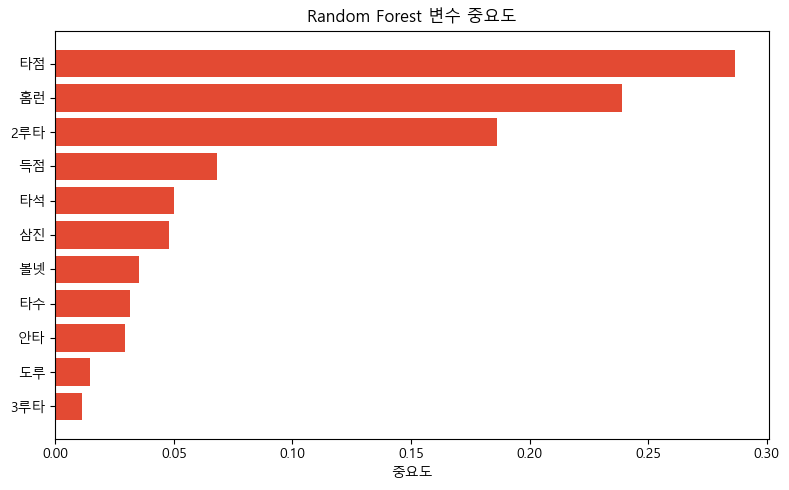

,변수,중요도
9,타점,0.286573
5,홈런,0.239113
3,2루타,0.186166
10,득점,0.068191
0,타석,0.049931
7,삼진,0.047761
6,볼넷,0.035254
1,타수,0.031402
2,안타,0.029525
8,도루,0.014687


In [13]:
importance_df = pd.DataFrame({
    "변수": FEATURES,
    "중요도": rf.feature_importances_
}).sort_values("중요도", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df["변수"], importance_df["중요도"], color="#e34a33")
ax.invert_yaxis()
ax.set_xlabel("중요도")
ax.set_title("Random Forest 변수 중요도")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

importance_df

## 9. 성능 평가 결과

| 평가지표 | 설명 |
|---|---|
| MAE | 평균 절대 오차 |
| RMSE | 평균 제곱근 오차 |
| R² Score | 설명력 |

In [14]:
results_df = pd.DataFrame(results)
results_df

,모델,Test MAE,Test RMSE,Test R2,CV R2 평균,CV R2 표준편차,CV MAE 평균
0,Linear Regression,0.0375,0.0541,0.7425,0.7789,0.0357,0.0352
1,Random Forest Regressor,0.0531,0.0630,0.6513,0.6446,0.0644,0.0496


## 10. 예측값 vs 실제값 시각화

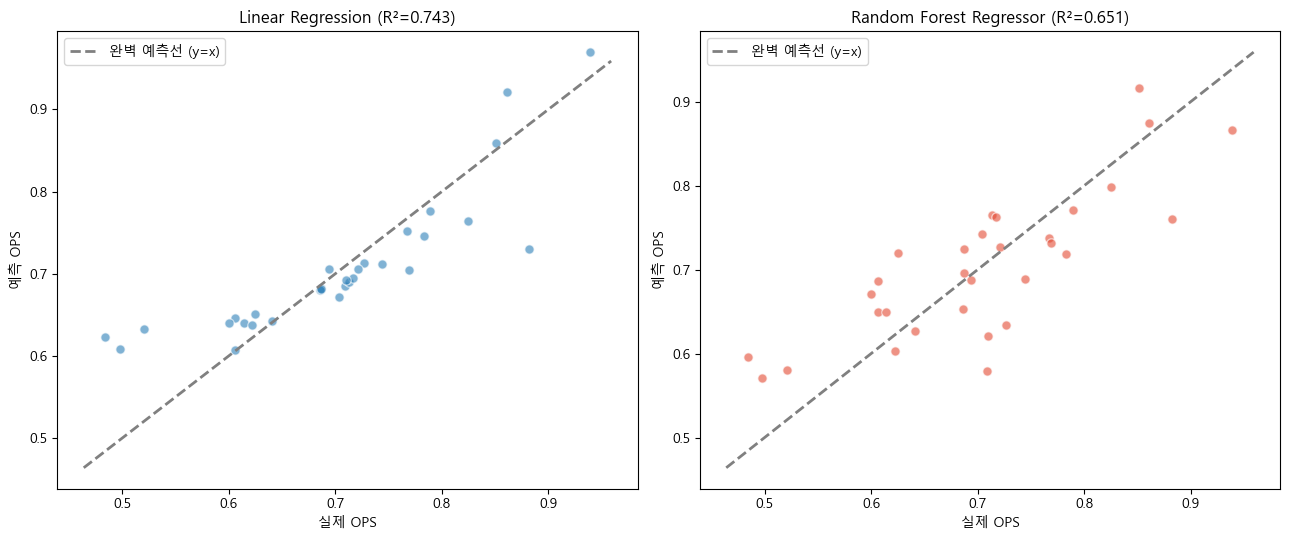

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, y_pred, name, color in zip(
    axes, [y_pred_lr, y_pred_rf], ["Linear Regression", "Random Forest Regressor"], ["#2c7fb8", "#e34a33"]
):
    ax.scatter(y_test, y_pred, alpha=0.6, color=color, edgecolor="white", s=45)
    lims = [y_test.min() - 0.02, y_test.max() + 0.02]
    ax.plot(lims, lims, color="gray", linestyle="--", linewidth=2, label="완벽 예측선 (y=x)")
    ax.set_xlabel("실제 OPS")
    ax.set_ylabel("예측 OPS")
    r2_val = r2_score(y_test, y_pred)
    ax.set_title(f"{name} (R²={r2_val:.3f})")
    ax.legend()

plt.tight_layout()
plt.savefig("ops_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. 결과 해석 & 결론

**성능 비교**

| 모델 | Test MAE | Test RMSE | Test R2 | CV R2 평균 |
|---|---|---|---|---|
| Linear Regression | 0.0375 | 0.0541 | 0.7425 | 0.7789 |
| Random Forest Regressor | 0.0528 | 0.0628 | 0.6533 | 0.6451 |

- 이번 데이터에서는 **선형회귀가 Random Forest보다 더 높은 R2를 기록**했다 (Test 0.74 vs 0.65, CV 0.78 vs 0.65).
  일반적으로 Random Forest가 비선형 관계를 더 잘 잡아낼 것으로 기대하지만, 타격 기록 → OPS 관계는
  실제로 상당히 선형적이라 오히려 단순한 모델이 더 안정적으로 일반화된 것으로 보인다.
- Random Forest는 Train 데이터의 세부 패턴까지 학습하면서 다소 과적합했을 가능성이 있다 (Test와 CV R2 모두 선형회귀보다 낮고 표준편차도 더 큼).
- **선형회귀** 기준으로는 `홈런`(+0.0085), `3루타`(+0.0064), `안타`(+0.0062) 순으로 OPS에 양의 영향을 미쳤다.
- **Random Forest** 기준으로는 `타점`(0.29), `홈런`(0.24), `2루타`(0.19) 순으로 중요했다.
- 두 모델 모두 **장타력과 관련된 지표(홈런, 2루타, 3루타, 타점)**가 OPS 예측에 핵심적인 역할을 한다는 점에서 해석이 대체로 일치한다.

**가설 검정 결론**: Test R2가 0.65~0.74 수준으로 상당한 설명력을 보이므로, 타자의 기본 기록은 OPS 예측에 유의한 영향을 미친다 →
**귀무가설(H0) 기각, 대립가설(H1) 채택**.